In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
df = pd.read_csv("train_data_preprocessed.csv")

In [3]:
target_cols = ["IC50, mM", "CC50, mM", "SI"]
X = df.drop(columns=target_cols + ["log10_IC50", "log10_CC50", "log10_SI"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_cc50 = df["CC50, mM"]
cc50_median = y_cc50.median()
y = (y_cc50 > cc50_median).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2,random_state=42,stratify=y)

In [4]:
models = {"LogisticRegression": LogisticRegression(max_iter=1000,C=1.0,class_weight=None),
    "RandomForest": RandomForestClassifier(n_estimators=300,max_depth=None,random_state=42,n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300,learning_rate=0.05,max_depth=3,random_state=42),}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    results.append((name, acc, roc_auc, f1))

results_df = pd.DataFrame(results, columns=["model", "Accuracy", "ROC_AUC", "F1"])
print(results_df.sort_values("ROC_AUC", ascending=False))

                model  Accuracy   ROC_AUC        F1
1        RandomForest  0.726368  0.850941  0.741784
2    GradientBoosting  0.731343  0.845248  0.745283
0  LogisticRegression  0.731343  0.833267  0.742857


Посмотрим все 3

In [5]:
from sklearn.model_selection import GridSearchCV

#Логистическая регрессия
log_reg = LogisticRegression(max_iter=5000)

param_grid_log = {"C": [0.1, 1.0, 10.0],"penalty": ["l2"],"class_weight": [None, "balanced"]}

grid_log = GridSearchCV(log_reg,param_grid_log,scoring="roc_auc",cv=3,n_jobs=-1)

grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_
y_pred_log = best_log.predict(X_test)
y_proba_log = best_log.predict_proba(X_test)[:, 1]

print("LogReg best params:", grid_log.best_params_)
print("LogReg best ROC-AUC (CV):", grid_log.best_score_)
print("LogReg test Accuracy:", accuracy_score(y_test, y_pred_log))
print("LogReg test ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print("LogReg test F1:", f1_score(y_test, y_pred_log))

LogReg best params: {'C': 0.1, 'class_weight': None, 'penalty': 'l2'}
LogReg best ROC-AUC (CV): 0.8185540019952248
LogReg test Accuracy: 0.7313432835820896
LogReg test ROC-AUC: 0.8371287128712871
LogReg test F1: 0.7522935779816514


Text(0.5, 1.0, 'Топ-20 признаков (LogisticRegression)')

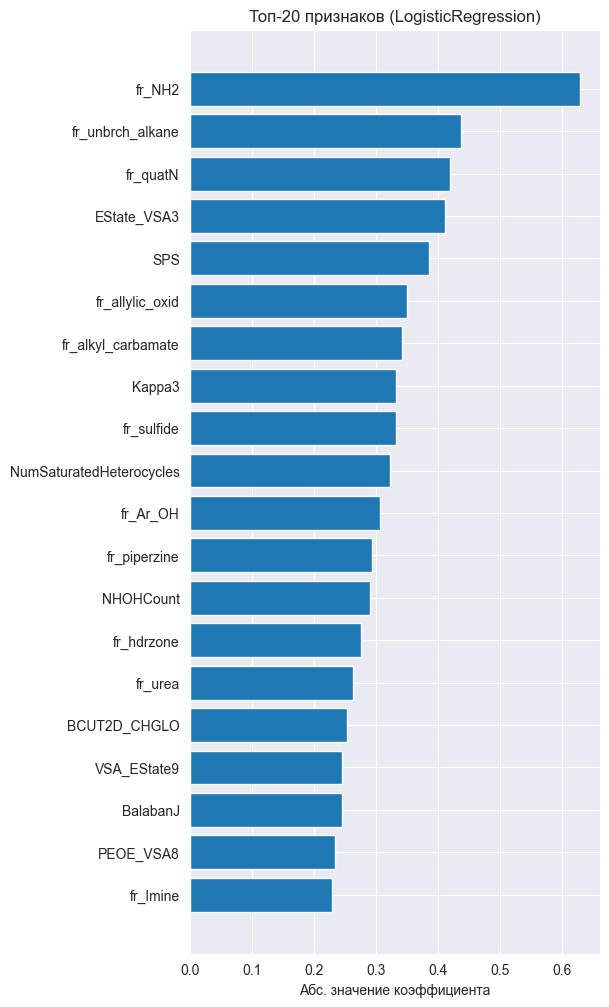

In [6]:
import matplotlib.pyplot as plt

feature_names = X.columns
plt.figure(figsize=(18, 12))

coeffs = np.abs(best_log.coef_[0])
idx_log = np.argsort(coeffs)[::-1][:20]
plt.subplot(1, 3, 1)
plt.barh(range(len(idx_log)), coeffs[idx_log][::-1])
plt.yticks(range(len(idx_log)), feature_names[idx_log][::-1])
plt.xlabel("Абс. значение коэффициента")
plt.title("Топ-20 признаков (LogisticRegression)")

In [7]:
#Forest
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid_rf = {"n_estimators": [200, 300, 500],"max_depth": [None, 10, 20],"min_samples_leaf": [1, 2, 4]}

grid_rf = GridSearchCV(rf_clf,param_grid_rf,scoring="roc_auc",cv=3,n_jobs=-1)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("RF best params:", grid_rf.best_params_)
print("RF best ROC-AUC (CV):", grid_rf.best_score_)
print("RF test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF test ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("RF test F1:", f1_score(y_test, y_pred_rf))

RF best params: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}
RF best ROC-AUC (CV): 0.8397962980619544
RF test Accuracy: 0.6965174129353234
RF test ROC-AUC: 0.8301980198019802
RF test F1: 0.7136150234741784


Text(0.5, 1.0, 'Топ-20 признаков (RandomForest)')

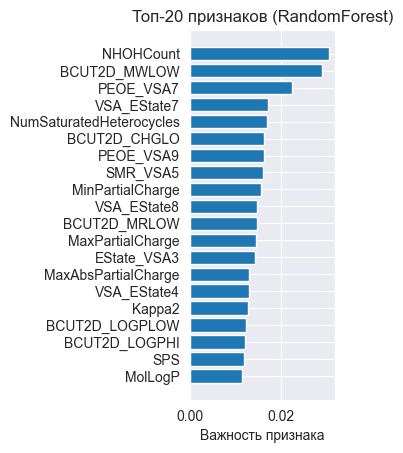

In [8]:
importances_rf = best_rf.feature_importances_
idx_rf = np.argsort(importances_rf)[::-1][:20]

plt.subplot(1, 3, 2)
plt.barh(range(len(idx_rf)), importances_rf[idx_rf][::-1])
plt.yticks(range(len(idx_rf)), feature_names[idx_rf][::-1])
plt.xlabel("Важность признака")
plt.title("Топ-20 признаков (RandomForest)")

In [9]:
#бустинг
gb_clf = GradientBoostingClassifier(random_state=42)

param_grid_gb = {"n_estimators": [200, 300, 500],"learning_rate": [0.03, 0.05, 0.1],"max_depth": [2, 3, 4]}

grid_gb = GridSearchCV(gb_clf,param_grid_gb,scoring="roc_auc",cv=3,n_jobs=-1)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

print("GB best params:", grid_gb.best_params_)
print("GB best ROC-AUC (CV):", grid_gb.best_score_)
print("GB test Accuracy:", accuracy_score(y_test, y_pred_gb))
print("GB test ROC-AUC:", roc_auc_score(y_test, y_proba_gb))
print("GB test F1:", f1_score(y_test, y_pred_gb))

GB best params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200}
GB best ROC-AUC (CV): 0.8359715780304763
GB test Accuracy: 0.7164179104477612
GB test ROC-AUC: 0.8306930693069307
GB test F1: 0.7323943661971831


Text(0.5, 1.0, 'Топ-20 признаков (GradientBoosting)')

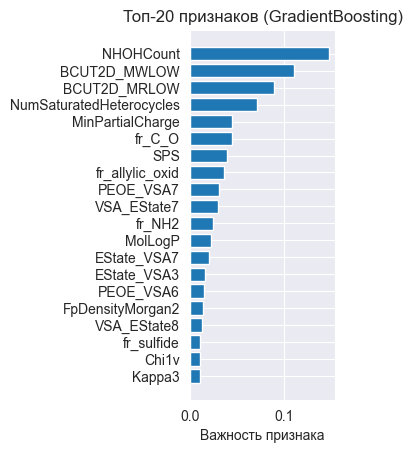

In [10]:
importances_gb = best_gb.feature_importances_
idx_gb = np.argsort(importances_gb)[::-1][:20]


plt.subplot(1, 3, 3)
plt.barh(range(len(idx_gb)), importances_gb[idx_gb][::-1])
plt.yticks(range(len(idx_gb)), feature_names[idx_gb][::-1])
plt.xlabel("Важность признака")
plt.title("Топ-20 признаков (GradientBoosting)")

Все алгоритмы показали сравнимое качество на тестовой выборке, но лучше оказались ансамблевые методы, после подбора гиперпараметров с помощью гридсерч были незначительно улучшены метрики. Ангализ коэффициентов показал связь с NHOHcount, BCUT2D и рядом VSA дескрипторов. Количество донорно‑акцепторных групп (NHOH) и некоторые структурные особенности скелета молекулы вносят решающий вклад в вероятность того, что соединение будет иметь более высокую цитотоксичность 